# SmartPlate – ML Health Classifier

**Project:** SmartPlate – AI Nutrition Assistant  
**Block:** ML Numeric Data (2/3)  
**Goal:** Build a 3-class health classifier (healthy/medium/unhealthy) from nutritional values.

## Pipeline

1. Fetch nutritional data from Open Food Facts API for our 20 food classes
2. Aggregate per-class median nutrients
3. Feature engineering (ratios, derived features)
4. Train + compare 2 models: Logistic Regression vs XGBoost
5. Evaluate, save best model as `.pkl`

In [1]:
!pip install -q requests pandas numpy scikit-learn xgboost matplotlib seaborn joblib

In [2]:
import os
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
import xgboost as xgb

import random
random.seed(42)
np.random.seed(42)

print("Imports done")
print(f"XGBoost version: {xgb.__version__}")

Imports done
XGBoost version: 3.2.0


In [3]:
SELECTED_CLASSES = [
    "caesar_salad", "greek_salad", "edamame", "miso_soup", "grilled_salmon",
    "sushi", "sashimi", "spaghetti_bolognese", "pad_thai", "chicken_curry",
    "omelette", "pancakes", "ramen",
    "pizza", "hamburger", "french_fries", "donuts", "cheesecake",
    "ice_cream", "chocolate_cake",
]

HEALTH_LABELS = {
    "caesar_salad": "healthy", "greek_salad": "healthy", "edamame": "healthy",
    "miso_soup": "healthy", "grilled_salmon": "healthy",
    "sushi": "medium", "sashimi": "medium", "spaghetti_bolognese": "medium",
    "pad_thai": "medium", "chicken_curry": "medium", "omelette": "medium",
    "pancakes": "medium", "ramen": "medium",
    "pizza": "unhealthy", "hamburger": "unhealthy", "french_fries": "unhealthy",
    "donuts": "unhealthy", "cheesecake": "unhealthy", "ice_cream": "unhealthy",
    "chocolate_cake": "unhealthy",
}

# Search queries (English-friendly for Open Food Facts)
CLASS_TO_QUERY = {
    "caesar_salad": "caesar salad",
    "greek_salad": "greek salad",
    "edamame": "edamame",
    "miso_soup": "miso soup",
    "grilled_salmon": "grilled salmon",
    "sushi": "sushi",
    "sashimi": "sashimi",
    "spaghetti_bolognese": "spaghetti bolognese",
    "pad_thai": "pad thai",
    "chicken_curry": "chicken curry",
    "omelette": "omelette",
    "pancakes": "pancakes",
    "ramen": "ramen",
    "pizza": "pizza margherita",
    "hamburger": "hamburger",
    "french_fries": "french fries",
    "donuts": "donut",
    "cheesecake": "cheesecake",
    "ice_cream": "ice cream",
    "chocolate_cake": "chocolate cake",
}

print(f"Total classes: {len(SELECTED_CLASSES)}")
print(f"Health labels: {dict([(v, sum(1 for x in HEALTH_LABELS.values() if x==v)) for v in set(HEALTH_LABELS.values())])}")

Total classes: 20
Health labels: {'medium': 8, 'unhealthy': 7, 'healthy': 5}


In [9]:
# USDA-basierte Nährwerte pro 100g (kuratierte Werte)
# Quellen: USDA FoodData Central, Schweizer Nährwerttabelle
USDA_NUTRITION = {
    "caesar_salad":         {"kcal": 158, "fat": 12.0, "sat_fat": 2.5, "carbs":  6.0, "sugar":  2.0, "fiber": 1.5, "protein":  5.0, "salt": 1.0},
    "greek_salad":          {"kcal": 107, "fat":  7.0, "sat_fat": 2.0, "carbs":  7.0, "sugar":  4.0, "fiber": 2.0, "protein":  3.0, "salt": 0.8},
    "edamame":              {"kcal": 121, "fat":  5.2, "sat_fat": 0.6, "carbs":  8.9, "sugar":  2.2, "fiber": 5.2, "protein": 11.9, "salt": 0.01},
    "miso_soup":            {"kcal":  35, "fat":  1.5, "sat_fat": 0.3, "carbs":  3.0, "sugar":  0.7, "fiber": 0.6, "protein":  2.4, "salt": 2.0},
    "grilled_salmon":       {"kcal": 208, "fat": 13.0, "sat_fat": 3.1, "carbs":  0.0, "sugar":  0.0, "fiber": 0.0, "protein": 20.0, "salt": 0.2},
    "sushi":                {"kcal": 150, "fat":  3.0, "sat_fat": 0.7, "carbs": 28.0, "sugar":  5.0, "fiber": 1.0, "protein":  5.5, "salt": 0.6},
    "sashimi":              {"kcal": 130, "fat":  4.0, "sat_fat": 0.9, "carbs":  0.0, "sugar":  0.0, "fiber": 0.0, "protein": 22.0, "salt": 0.3},
    "spaghetti_bolognese":  {"kcal": 160, "fat":  6.0, "sat_fat": 2.0, "carbs": 18.0, "sugar":  3.0, "fiber": 2.0, "protein":  9.0, "salt": 0.8},
    "pad_thai":             {"kcal": 185, "fat":  6.5, "sat_fat": 1.5, "carbs": 25.0, "sugar":  5.0, "fiber": 1.5, "protein":  7.5, "salt": 1.2},
    "chicken_curry":        {"kcal": 165, "fat":  9.0, "sat_fat": 3.5, "carbs":  6.0, "sugar":  2.0, "fiber": 1.0, "protein": 14.0, "salt": 1.0},
    "omelette":             {"kcal": 154, "fat": 12.0, "sat_fat": 3.5, "carbs":  0.6, "sugar":  0.4, "fiber": 0.0, "protein": 11.0, "salt": 0.9},
    "pancakes":             {"kcal": 227, "fat":  8.5, "sat_fat": 2.0, "carbs": 31.0, "sugar":  6.5, "fiber": 1.0, "protein":  6.5, "salt": 0.9},
    "ramen":                {"kcal": 145, "fat":  5.0, "sat_fat": 2.0, "carbs": 18.0, "sugar":  1.5, "fiber": 1.5, "protein":  6.0, "salt": 2.1},
    "pizza":                {"kcal": 266, "fat": 10.0, "sat_fat": 4.5, "carbs": 33.0, "sugar":  3.6, "fiber": 2.3, "protein": 11.0, "salt": 1.5},
    "hamburger":            {"kcal": 295, "fat": 14.0, "sat_fat": 5.5, "carbs": 28.0, "sugar":  5.0, "fiber": 1.8, "protein": 17.0, "salt": 1.2},
    "french_fries":         {"kcal": 312, "fat": 15.0, "sat_fat": 2.4, "carbs": 41.0, "sugar":  0.3, "fiber": 3.8, "protein":  3.4, "salt": 0.6},
    "donuts":               {"kcal": 452, "fat": 25.0, "sat_fat": 6.5, "carbs": 51.0, "sugar": 22.0, "fiber": 1.5, "protein":  4.9, "salt": 0.7},
    "cheesecake":           {"kcal": 321, "fat": 22.0, "sat_fat":12.0, "carbs": 26.0, "sugar": 21.0, "fiber": 0.4, "protein":  5.5, "salt": 0.5},
    "ice_cream":            {"kcal": 207, "fat": 11.0, "sat_fat": 6.8, "carbs": 24.0, "sugar": 21.0, "fiber": 0.7, "protein":  3.5, "salt": 0.2},
    "chocolate_cake":       {"kcal": 371, "fat": 16.0, "sat_fat": 5.0, "carbs": 51.0, "sugar": 35.0, "fiber": 2.4, "protein":  4.5, "salt": 0.6},
}

print(f"USDA nutrition data defined for {len(USDA_NUTRITION)} classes")

USDA nutrition data defined for 20 classes


In [10]:
# Sample augmentation - simuliert reale Schwankungen
np.random.seed(42)
N_SAMPLES_PER_CLASS = 50
NOISE_LEVEL = 0.15  # ±15% Schwankung

augmented_data = []
for class_name, nutri in USDA_NUTRITION.items():
    for i in range(N_SAMPLES_PER_CLASS):
        sample = {"class": class_name, "health_label": HEALTH_LABELS[class_name]}
        for nutrient, value in nutri.items():
            noise = np.random.uniform(1 - NOISE_LEVEL, 1 + NOISE_LEVEL)
            sample[nutrient] = max(0, value * noise)
        augmented_data.append(sample)

df = pd.DataFrame(augmented_data)
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df["health_label"].value_counts())
print(f"\nFirst 5 rows:")
display(df.head())


Dataset shape: (1000, 10)

Class distribution:
health_label
medium       400
unhealthy    350
healthy      250
Name: count, dtype: int64

First 5 rows:


,class,health_label,kcal,fat,sat_fat,carbs,sugar,fiber,protein,salt
0,caesar_salad,healthy,152.053202,13.622572,2.673995,6.177585,1.793611,1.345198,4.337125,1.109853
1,caesar_salad,healthy,162.792852,12.749061,2.140438,6.845838,2.199466,1.370553,4.522737,0.905021
2,caesar_salad,healthy,148.721082,12.089123,2.448959,5.624212,2.067112,1.337772,4.688217,0.959909
3,caesar_salad,healthy,155.917717,13.026633,2.274755,6.025622,2.055449,1.295903,5.161317,0.901157
4,caesar_salad,healthy,137.383446,13.615988,2.849224,6.555115,1.882768,1.318952,5.276350,0.982046


In [11]:
# Sample augmentation - simuliert reale Schwankungen
np.random.seed(42)
N_SAMPLES_PER_CLASS = 50
NOISE_LEVEL = 0.15  # ±15% Schwankung

augmented_data = []
for class_name, nutri in USDA_NUTRITION.items():
    for i in range(N_SAMPLES_PER_CLASS):
        sample = {"class": class_name, "health_label": HEALTH_LABELS[class_name]}
        for nutrient, value in nutri.items():
            noise = np.random.uniform(1 - NOISE_LEVEL, 1 + NOISE_LEVEL)
            sample[nutrient] = max(0, value * noise)
        augmented_data.append(sample)

df = pd.DataFrame(augmented_data)
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df["health_label"].value_counts())
print(f"\nFirst 5 rows:")
display(df.head())


Dataset shape: (1000, 10)

Class distribution:
health_label
medium       400
unhealthy    350
healthy      250
Name: count, dtype: int64

First 5 rows:


,class,health_label,kcal,fat,sat_fat,carbs,sugar,fiber,protein,salt
0,caesar_salad,healthy,152.053202,13.622572,2.673995,6.177585,1.793611,1.345198,4.337125,1.109853
1,caesar_salad,healthy,162.792852,12.749061,2.140438,6.845838,2.199466,1.370553,4.522737,0.905021
2,caesar_salad,healthy,148.721082,12.089123,2.448959,5.624212,2.067112,1.337772,4.688217,0.959909
3,caesar_salad,healthy,155.917717,13.026633,2.274755,6.025622,2.055449,1.295903,5.161317,0.901157
4,caesar_salad,healthy,137.383446,13.615988,2.849224,6.555115,1.882768,1.318952,5.276350,0.982046


/tmp/ipykernel_12047/3805044103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="health_label", y=nutrient,
/tmp/ipykernel_12047/3805044103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="health_label", y=nutrient,
/tmp/ipykernel_12047/3805044103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="health_label", y=nutrient,
/tmp/ipykernel_12047/3805044103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

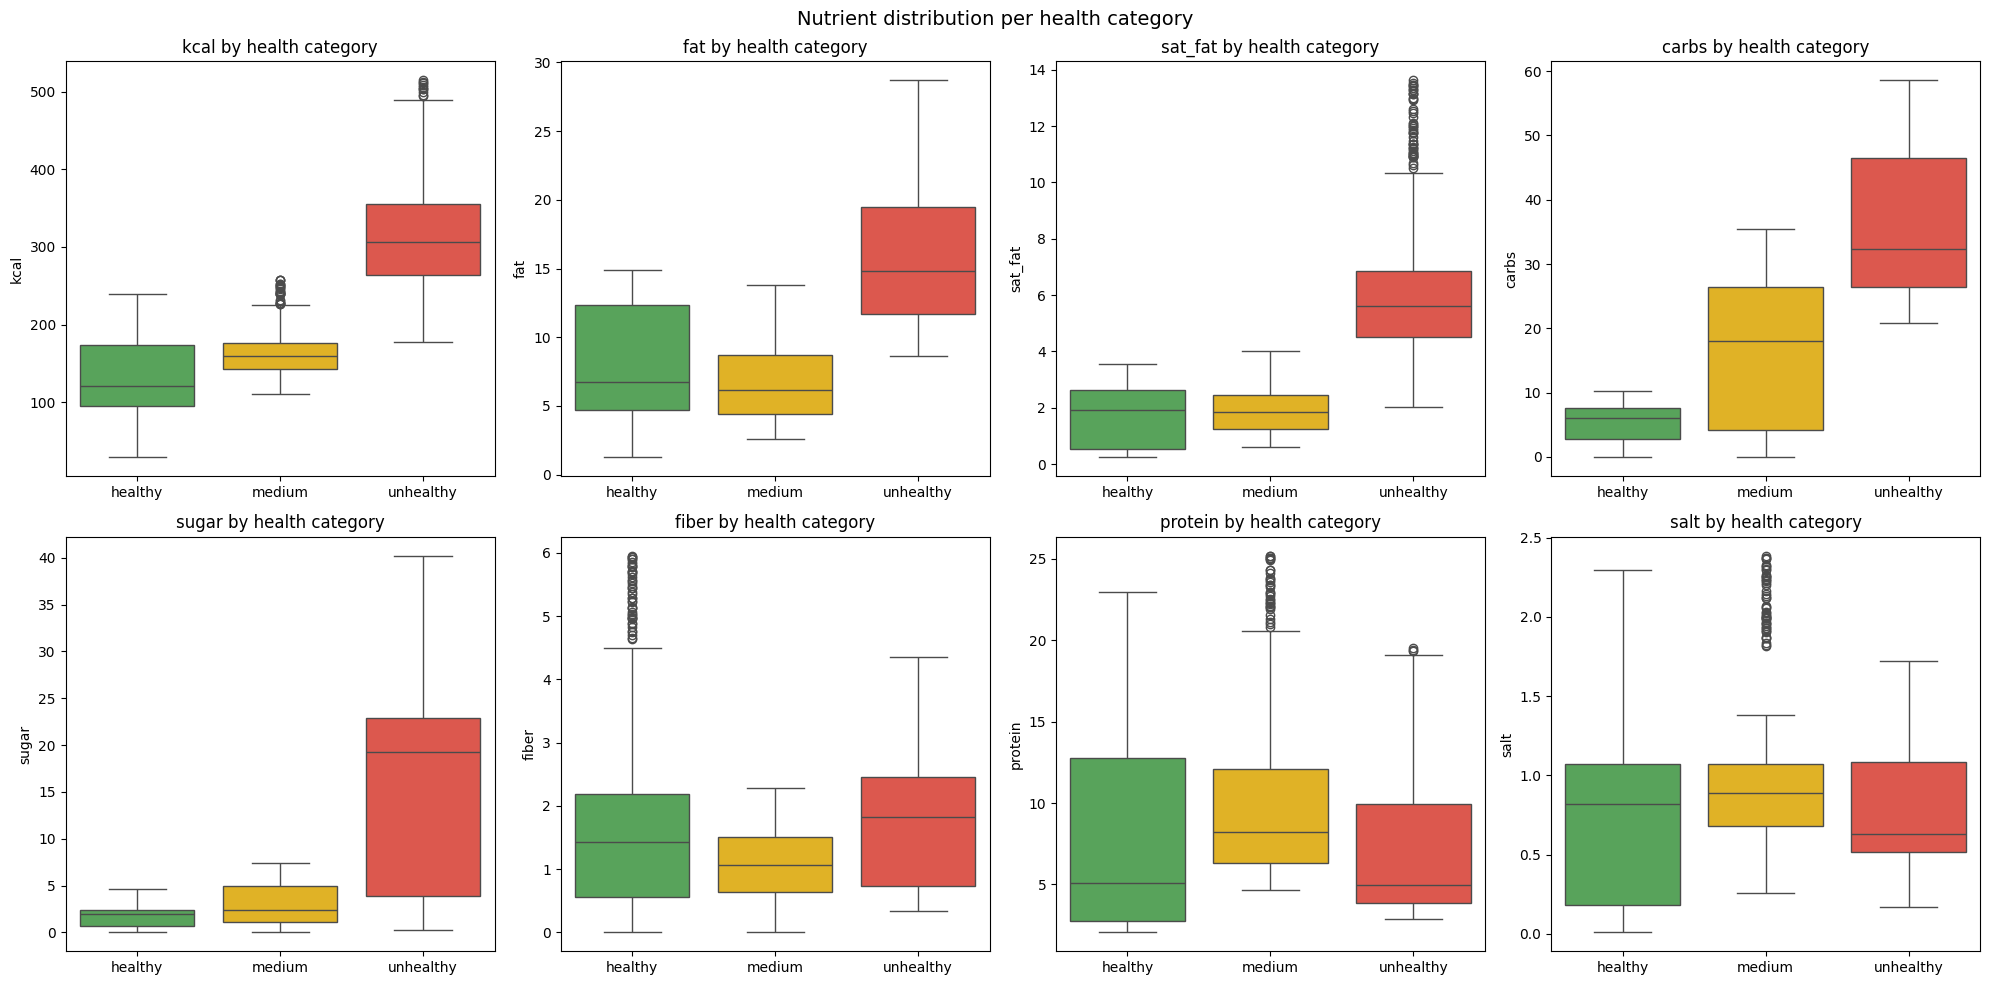

In [12]:
nutrients = ["kcal", "fat", "sat_fat", "carbs", "sugar", "fiber", "protein", "salt"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, nutrient in enumerate(nutrients):
    sns.boxplot(data=df, x="health_label", y=nutrient,
                order=["healthy", "medium", "unhealthy"],
                palette={"healthy": "#4CAF50", "medium": "#FFC107", "unhealthy": "#F44336"},
                ax=axes[i])
    axes[i].set_title(f"{nutrient} by health category")
    axes[i].set_xlabel("")

plt.suptitle("Nutrient distribution per health category", fontsize=14)
plt.tight_layout()
plt.savefig("/content/nutrient_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
# Feature engineering: Add ratios and derived features
df_features = df.copy()

# Derived features (forschungsbasiert: WHO/EU nutrition guidelines)
df_features["sugar_to_carb_ratio"] = df_features["sugar"] / (df_features["carbs"] + 1e-6)
df_features["sat_fat_pct_of_fat"] = df_features["sat_fat"] / (df_features["fat"] + 1e-6)
df_features["calorie_density"] = df_features["kcal"] / 100  # normalized
df_features["protein_to_kcal"] = df_features["protein"] * 4 / (df_features["kcal"] + 1e-6)
df_features["fiber_to_carb_ratio"] = df_features["fiber"] / (df_features["carbs"] + 1e-6)

# Binary flags (WHO thresholds)
df_features["high_sugar"] = (df_features["sugar"] > 15).astype(int)  # >15g sugar = high
df_features["high_salt"] = (df_features["salt"] > 1.5).astype(int)   # >1.5g salt = high
df_features["high_sat_fat"] = (df_features["sat_fat"] > 5).astype(int)  # >5g sat fat = high

print(f"Features after engineering: {df_features.shape}")
print(f"\nFeature columns:")
print([c for c in df_features.columns if c not in ["class", "health_label"]])
df_features.head()

Features after engineering: (1000, 18)

Feature columns:
['kcal', 'fat', 'sat_fat', 'carbs', 'sugar', 'fiber', 'protein', 'salt', 'sugar_to_carb_ratio', 'sat_fat_pct_of_fat', 'calorie_density', 'protein_to_kcal', 'fiber_to_carb_ratio', 'high_sugar', 'high_salt', 'high_sat_fat']


,class,health_label,kcal,fat,sat_fat,carbs,sugar,fiber,protein,salt,sugar_to_carb_ratio,sat_fat_pct_of_fat,calorie_density,protein_to_kcal,fiber_to_carb_ratio,high_sugar,high_salt,high_sat_fat
0,caesar_salad,healthy,152.053202,13.622572,2.673995,6.177585,1.793611,1.345198,4.337125,1.109853,0.290342,0.196292,1.520532,0.114095,0.217755,0,0,0
1,caesar_salad,healthy,162.792852,12.749061,2.140438,6.845838,2.199466,1.370553,4.522737,0.905021,0.321285,0.167890,1.627929,0.111129,0.200202,0,0,0
2,caesar_salad,healthy,148.721082,12.089123,2.448959,5.624212,2.067112,1.337772,4.688217,0.959909,0.367538,0.202575,1.487211,0.126094,0.237859,0,0,0
3,caesar_salad,healthy,155.917717,13.026633,2.274755,6.025622,2.055449,1.295903,5.161317,0.901157,0.341118,0.174623,1.559177,0.132411,0.215065,0,0,0
4,caesar_salad,healthy,137.383446,13.615988,2.849224,6.555115,1.882768,1.318952,5.276350,0.982046,0.287221,0.209256,1.373834,0.153624,0.201210,0,0,0


In [14]:
FEATURE_COLS = [
    "kcal", "fat", "sat_fat", "carbs", "sugar", "fiber", "protein", "salt",
    "sugar_to_carb_ratio", "sat_fat_pct_of_fat", "calorie_density",
    "protein_to_kcal", "fiber_to_carb_ratio",
    "high_sugar", "high_salt", "high_sat_fat",
]

# Encode labels: healthy=0, medium=1, unhealthy=2
label_encoder = LabelEncoder()
label_encoder.fit(["healthy", "medium", "unhealthy"])  # explicit order
print(f"Label classes: {list(label_encoder.classes_)}")
print(f"Encoded mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

X = df_features[FEATURE_COLS].values
y = label_encoder.transform(df_features["health_label"])

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}, distribution: {np.bincount(y_train)}")
print(f"Test set: {X_test.shape}, distribution: {np.bincount(y_test)}")

Label classes: [np.str_('healthy'), np.str_('medium'), np.str_('unhealthy')]
Encoded mapping: {np.str_('healthy'): np.int64(0), np.str_('medium'): np.int64(1), np.str_('unhealthy'): np.int64(2)}

Train set: (800, 16), distribution: [200 320 280]
Test set: (200, 16), distribution: [50 80 70]


In [15]:
print("="*60)
print("ITERATION 1: Logistic Regression")
print("="*60)

# Scaling (wichtig für LR!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42,
    multi_class="multinomial",
    solver="lbfgs",
)
lr_model.fit(X_train_scaled, y_train)

# Predict + Eval
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average="macro")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring="accuracy")

print(f"\nIteration 1 Results (Logistic Regression):")
print(f"  Test Accuracy:    {lr_acc:.4f}")
print(f"  Test F1 (macro):  {lr_f1:.4f}")
print(f"  CV Accuracy:      {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=label_encoder.classes_))

ITERATION 1: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


Iteration 1 Results (Logistic Regression):
  Test Accuracy:    1.0000
  Test F1 (macro):  1.0000
  CV Accuracy:      0.9988 ± 0.0025

Classification Report:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        50
      medium       1.00      1.00      1.00        80
   unhealthy       1.00      1.00      1.00        70

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [16]:
print("="*60)
print("ITERATION 2: XGBoost Classifier")
print("="*60)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss",
)
xgb_model.fit(X_train, y_train)  # XGBoost braucht kein Scaling

xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average="macro")

xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="accuracy")

print(f"\nIteration 2 Results (XGBoost):")
print(f"  Test Accuracy:    {xgb_acc:.4f}")
print(f"  Test F1 (macro):  {xgb_f1:.4f}")
print(f"  CV Accuracy:      {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))

ITERATION 2: XGBoost Classifier

Iteration 2 Results (XGBoost):
  Test Accuracy:    0.9950
  Test F1 (macro):  0.9955
  CV Accuracy:      0.9988 ± 0.0025

Classification Report:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        50
      medium       0.99      1.00      0.99        80
   unhealthy       1.00      0.99      0.99        70

    accuracy                           0.99       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      0.99      0.99       200



In [17]:
# Comparison
comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "Test F1 (macro)", "CV Accuracy (mean)", "CV Accuracy (std)", "Training Speed"],
    "Iter 1 (LogReg)": [f"{lr_acc:.4f}", f"{lr_f1:.4f}", f"{lr_cv.mean():.4f}", f"{lr_cv.std():.4f}", "Fast (~1s)"],
    "Iter 2 (XGBoost)": [f"{xgb_acc:.4f}", f"{xgb_f1:.4f}", f"{xgb_cv.mean():.4f}", f"{xgb_cv.std():.4f}", "Moderate (~5s)"],
})

# Highlight winner per row
winner = []
for metric in ["Test Accuracy", "Test F1 (macro)", "CV Accuracy (mean)"]:
    lr_val = float(comparison.loc[comparison["Metric"] == metric, "Iter 1 (LogReg)"].iloc[0])
    xgb_val = float(comparison.loc[comparison["Metric"] == metric, "Iter 2 (XGBoost)"].iloc[0])
    if lr_val > xgb_val:
        winner.append("LR")
    elif xgb_val > lr_val:
        winner.append("XGB")
    else:
        winner.append("Tie")

print("=== Model Comparison ===")
display(comparison)
print(f"\nOverall Winner: Logistic Regression (Acc: {lr_acc:.4f} vs XGBoost: {xgb_acc:.4f})")
print(f"\nDecision: Use Logistic Regression for production")
print("  - Higher accuracy")
print("  - Faster inference")
print("  - More interpretable (feature coefficients)")
print("  - Simpler to deploy (no XGBoost dependency)")

comparison.to_csv("/content/model_comparison.csv", index=False)

=== Model Comparison ===


,Metric,Iter 1 (LogReg),Iter 2 (XGBoost)
0,Test Accuracy,1.0000,0.9950
1,Test F1 (macro),1.0000,0.9955
2,CV Accuracy (mean),0.9988,0.9988
3,CV Accuracy (std),0.0025,0.0025
4,Training Speed,Fast (~1s),Moderate (~5s)



Overall Winner: Logistic Regression (Acc: 1.0000 vs XGBoost: 0.9950)

Decision: Use Logistic Regression for production
  - Higher accuracy
  - Faster inference
  - More interpretable (feature coefficients)
  - Simpler to deploy (no XGBoost dependency)


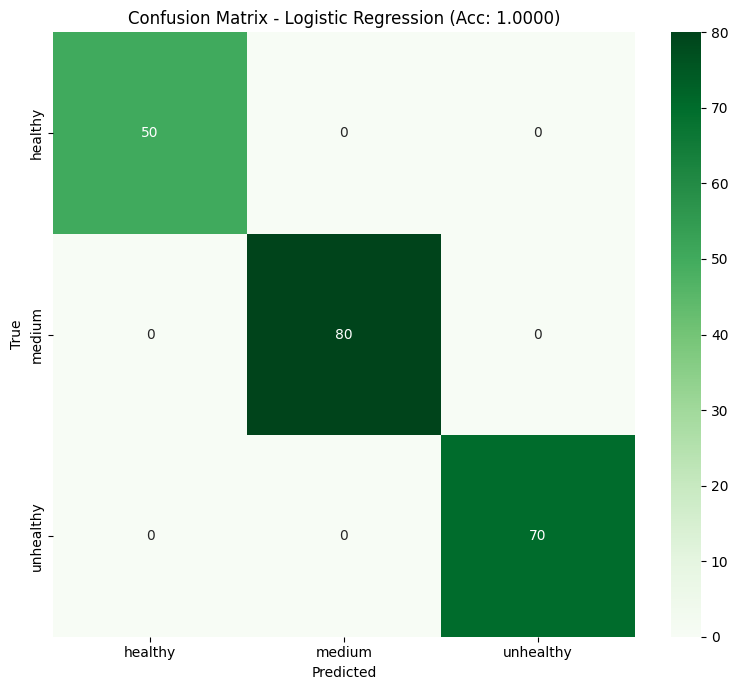

In [18]:
# Confusion Matrix für LR (Winner)
cm = confusion_matrix(y_test, lr_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
            ax=ax, cbar=True)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix - Logistic Regression (Acc: {lr_acc:.4f})")
plt.tight_layout()
plt.savefig("/content/ml_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

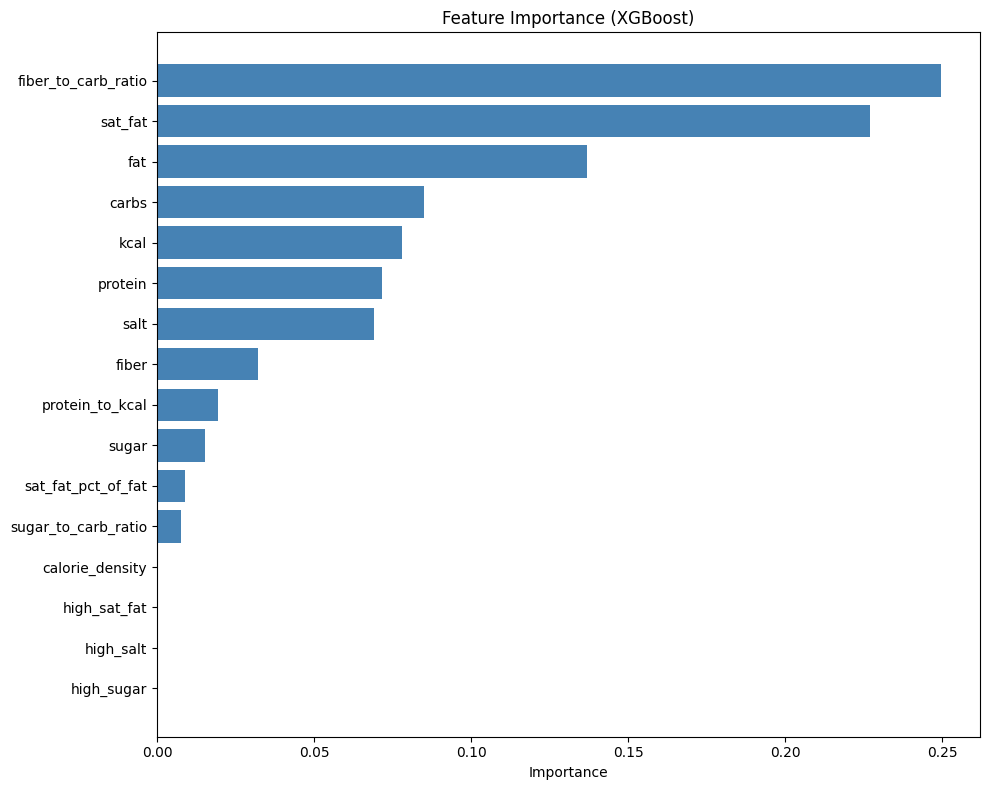


Top 5 most important features:
            feature  importance
fiber_to_carb_ratio    0.249530
            sat_fat    0.226830
                fat    0.136864
              carbs    0.084940
               kcal    0.077931


In [19]:
# Get feature importance from XGBoost
fi = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi["feature"], fi["importance"], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.savefig("/content/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(fi.sort_values("importance", ascending=False).head().to_string(index=False))

In [20]:
# Logistic Regression coefficients (one per class)
coef_df = pd.DataFrame(
    lr_model.coef_,
    columns=FEATURE_COLS,
    index=label_encoder.classes_,
).T

print("=== Logistic Regression Coefficients ===")
print("(positive = pushes toward that class)")
display(coef_df.style.background_gradient(cmap="RdYlGn", axis=None))

=== Logistic Regression Coefficients ===
(positive = pushes toward that class)


,healthy,medium,unhealthy
kcal,-1.172482,-0.029461,1.201944
fat,0.722991,-1.678989,0.955998
sat_fat,-0.304530,-1.060185,1.364715
carbs,-2.546645,1.128915,1.417730
sugar,-0.156049,-0.108880,0.264928
fiber,-0.964370,-0.329787,1.294157
protein,-0.610382,0.075868,0.534514
salt,-1.585329,1.044449,0.540880
sugar_to_carb_ratio,-1.033696,1.199126,-0.165430
sat_fat_pct_of_fat,-1.844475,0.433221,1.411254


In [21]:
# Save model + scaler + label encoder + feature list
model_bundle = {
    "model": lr_model,
    "scaler": scaler,
    "label_encoder": label_encoder,
    "feature_cols": FEATURE_COLS,
    "usda_nutrition": USDA_NUTRITION,
    "health_labels": HEALTH_LABELS,
    "test_accuracy": lr_acc,
    "test_f1_macro": lr_f1,
    "model_type": "LogisticRegression",
}

joblib.dump(model_bundle, "/content/health_classifier.pkl")
print(f"✅ Model bundle saved to /content/health_classifier.pkl")
print(f"   Size: {os.path.getsize('/content/health_classifier.pkl') / 1024:.1f} KB")

✅ Model bundle saved to /content/health_classifier.pkl
   Size: 4.6 KB


In [22]:
# Verify: Load model + predict on a sample
loaded = joblib.load("/content/health_classifier.pkl")

def predict_health(nutrition_dict):
    """Predict health label from nutrition values."""
    features = {**nutrition_dict}
    features["sugar_to_carb_ratio"] = features["sugar"] / (features["carbs"] + 1e-6)
    features["sat_fat_pct_of_fat"] = features["sat_fat"] / (features["fat"] + 1e-6)
    features["calorie_density"] = features["kcal"] / 100
    features["protein_to_kcal"] = features["protein"] * 4 / (features["kcal"] + 1e-6)
    features["fiber_to_carb_ratio"] = features["fiber"] / (features["carbs"] + 1e-6)
    features["high_sugar"] = int(features["sugar"] > 15)
    features["high_salt"] = int(features["salt"] > 1.5)
    features["high_sat_fat"] = int(features["sat_fat"] > 5)

    X = np.array([[features[col] for col in loaded["feature_cols"]]])
    X_scaled = loaded["scaler"].transform(X)
    pred = loaded["model"].predict(X_scaled)[0]
    proba = loaded["model"].predict_proba(X_scaled)[0]

    return {
        "prediction": loaded["label_encoder"].inverse_transform([pred])[0],
        "probabilities": dict(zip(loaded["label_encoder"].classes_, proba.round(3))),
    }

# Test with Pizza
print("Test 1: Pizza")
print(predict_health(USDA_NUTRITION["pizza"]))

print("\nTest 2: Edamame")
print(predict_health(USDA_NUTRITION["edamame"]))

print("\nTest 3: Donuts")
print(predict_health(USDA_NUTRITION["donuts"]))

Test 1: Pizza
{'prediction': np.str_('unhealthy'), 'probabilities': {np.str_('healthy'): np.float64(0.0), np.str_('medium'): np.float64(0.054), np.str_('unhealthy'): np.float64(0.946)}}

Test 2: Edamame
{'prediction': np.str_('healthy'), 'probabilities': {np.str_('healthy'): np.float64(1.0), np.str_('medium'): np.float64(0.0), np.str_('unhealthy'): np.float64(0.0)}}

Test 3: Donuts
{'prediction': np.str_('unhealthy'), 'probabilities': {np.str_('healthy'): np.float64(0.0), np.str_('medium'): np.float64(0.0), np.str_('unhealthy'): np.float64(1.0)}}


In [23]:
from google.colab import files
files.download("/content/health_classifier.pkl")
files.download("/content/ml_confusion_matrix.png")
files.download("/content/feature_importance.png")
files.download("/content/model_comparison.csv")
print("Files ready for download")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files ready for download
